# FASE 2

In [5]:
import pandas as pd
import numpy as np
# Operaciones numéricas
import matplotlib.pyplot as plt # Gráficos base
import seaborn as sns
# Visualización estadística avanzada

Carga del dataset

In [6]:
df = pd.read_csv('all_games.csv')

Visualización de la estructura (Primeros 5 registros)

In [7]:
print("--- Primeros registros ---")
print(df.head())

--- Primeros registros ---
                                   name        platform        release_date  \
0  The Legend of Zelda: Ocarina of Time     Nintendo 64   November 23, 1998   
1              Tony Hawk's Pro Skater 2     PlayStation  September 20, 2000   
2                   Grand Theft Auto IV   PlayStation 3      April 29, 2008   
3                           SoulCalibur       Dreamcast   September 8, 1999   
4                   Grand Theft Auto IV        Xbox 360      April 29, 2008   

                                             summary  meta_score user_review  
0  As a young boy, Link is tricked by Ganondorf, ...          99         9.1  
1  As most major publishers' development efforts ...          98         7.4  
2  [Metacritic's 2008 PS3 Game of the Year; Also ...          98         7.7  
3  This is a tale of souls and swords, transcendi...          98         8.4  
4  [Metacritic's 2008 Xbox 360 Game of the Year; ...          98         7.9  


Determinación del volumen total (filas, columnas)

In [8]:
print(f"\nDimensiones del dataset: {df.shape}")


Dimensiones del dataset: (18800, 6)


Información general y tipos de datos

In [9]:
print("--- Información del Dataframe ---")
df.info()

--- Información del Dataframe ---
<class 'pandas.DataFrame'>
RangeIndex: 18800 entries, 0 to 18799
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   name          18800 non-null  str  
 1   platform      18800 non-null  str  
 2   release_date  18800 non-null  str  
 3   summary       18686 non-null  str  
 4   meta_score    18800 non-null  int64
 5   user_review   18800 non-null  str  
dtypes: int64(1), str(5)
memory usage: 881.4 KB


Estadísticas descriptivas de la crítica (meta_score)

In [10]:
print("\n--- Resumen Estadístico ---")
print(df.describe())


--- Resumen Estadístico ---
         meta_score
count  18800.000000
mean      70.648883
std       12.225006
min       20.000000
25%       64.000000
50%       72.000000
75%       80.000000
max       99.000000


Frecuencia de juegos por plataforma

In [11]:
print("\n--- Top 10 Plataformas con más juegos ---")
print(df['platform'].value_counts().head(10))


--- Top 10 Plataformas con más juegos ---
platform
PC               4864
PlayStation 4    2056
Xbox 360         1644
PlayStation 2    1414
Switch           1399
PlayStation 3    1256
Xbox One         1179
Xbox              789
DS                720
Wii               655
Name: count, dtype: int64


Visualización de la distribución de meta_score

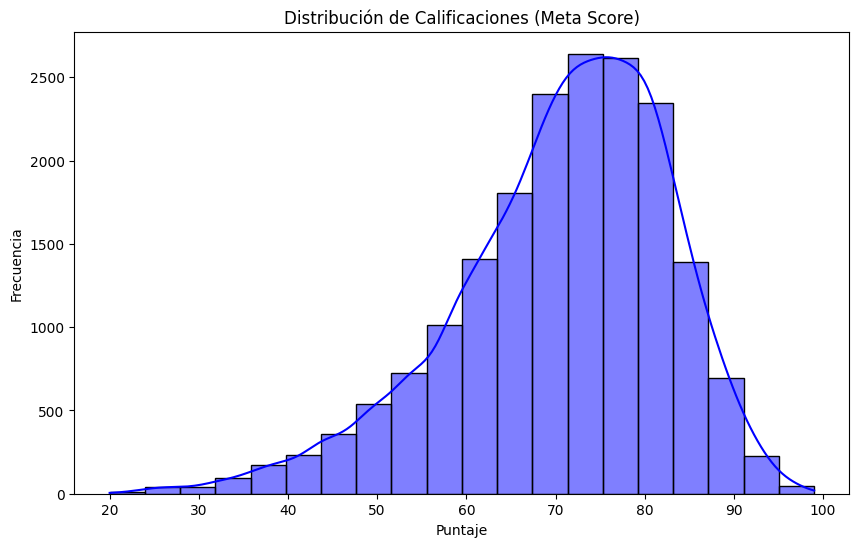

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df['meta_score'], bins=20, kde=True, color='blue')
plt.title('Distribución de Calificaciones (Meta Score)')
plt.xlabel('Puntaje')
plt.ylabel('Frecuencia')
plt.show()

Detección de valores nulos

In [13]:
print("\n--- Valores faltantes por columna ---")
print(df.isnull().sum())


--- Valores faltantes por columna ---
name              0
platform          0
release_date      0
summary         114
meta_score        0
user_review       0
dtype: int64


Identificación de duplicados

In [14]:
print(f"\nCantidad de filas duplicadas: {df.duplicated().sum()}")


Cantidad de filas duplicadas: 0


Detección de inconsistencias en reseñas de usuario

In [15]:
print("\n--- Valores únicos en User Review (Muestra) ---")
print(df['user_review'].unique()[:20]) # Permite ver el valor "tbd"


--- Valores únicos en User Review (Muestra) ---
<StringArray>
['9.1', '7.4', '7.7', '8.4', '7.9', '8.0', '8.3', '6.2', '8.7', '7.5', '8.8',
 '8.5', '8.6', '8.9', '8.2', '9.2', '7.8', '9.0', '9.3', '8.1']
Length: 20, dtype: str


# FASE 3

In [16]:
import re

# Cargar el dataset

In [17]:
df = pd.read_csv('all_games.csv')

# 1. Convertir 'user_review' a numérico, transformando 'tbd' en NaN
(Not a Number)

In [18]:
df['user_review'] = pd.to_numeric(df['user_review'], errors='coerce')

# 2. Manejo de valores nulos
# Decisión: Llenar nulos en 'summary' con "No description available"

In [19]:
df['summary'] = df['summary'].fillna("No description available")

In [20]:
print("\n--- Valores faltantes por columna ---")
print(df.isnull().sum())


--- Valores faltantes por columna ---
name               0
platform           0
release_date       0
summary            0
meta_score         0
user_review     1365
dtype: int64


# Eliminar filas donde 'user_review' es NaN si nuestro objetivo es comparar scores

In [21]:
df_clean = df.dropna(subset=['user_review']).copy()

# 1. Extraer el Año de lanzamiento de la columna 'release_date'

In [22]:
df_clean['release_year'] = pd.to_datetime(df_clean['release_date']).dt.year

# 2. Crear la "Brecha de Percepción" (Diferencia entre Crítica y Usuarios)
# Nota: Escalamos user_review (0-10) a la misma escala que meta_score (0-100)

In [23]:
df_clean['score_diff'] = df_clean['meta_score'] - (df_clean['user_review'] * 10)

# C. Integración y Formateo, aseguramos que el dataset sea consistente y fácil de procesar.
# 1. Eliminar espacios en blanco innecesarios en nombres de columnas y textos

In [24]:
df_clean['name'] = df_clean['name'].str.strip()

# 2. Selección de columnas finales para el modelado

In [25]:
df_final = df_clean[['name', 'platform', 'release_year', 'meta_score', 'user_review', 'score_diff']]
print("Dataset preparado. Filas restantes:", len(df_final))

Dataset preparado. Filas restantes: 17435


# 3. Checkpoint de Calidad (Validación Técnica), ejecuta este bloque de código para confirmar que el dataframe df_final cumple con los requisitos de la fase de preparación:
# 1. Validación de tipos de datos

In [26]:
check_types = df_final['user_review'].dtype == 'float64'
print(f"¿Columna 'user_review' es float64?: {check_types}")

¿Columna 'user_review' es float64?: True


# 2. Validación de valores nulos

In [27]:
null_count = df_final.isnull().sum().sum()
print(f"¿Valores nulos totales en el set final?: {null_count}")

¿Valores nulos totales en el set final?: 0


# 3. Validación de formato temporal

In [28]:
check_year = 'release_year' in df_final.columns and df_final['release_year'].dtype == 'int32'
print(f"¿Variable temporal 'release_year' lista?: {check_year}")
print("--- Información del Dataframe ---")
df_final.info()

¿Variable temporal 'release_year' lista?: True
--- Información del Dataframe ---
<class 'pandas.DataFrame'>
Index: 17435 entries, 0 to 18799
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          17435 non-null  str    
 1   platform      17435 non-null  str    
 2   release_year  17435 non-null  int32  
 3   meta_score    17435 non-null  int64  
 4   user_review   17435 non-null  float64
 5   score_diff    17435 non-null  float64
dtypes: float64(2), int32(1), int64(1), str(2)
memory usage: 885.4 KB


# 4. Vista previa de la consistencia (Primeras 5 filas)

In [29]:
print("\n--- Verificación de Consistencia de Datos ---")
print(df_final[['name', 'meta_score', 'user_review', 'score_diff']].head())


--- Verificación de Consistencia de Datos ---
                                   name  meta_score  user_review  score_diff
0  The Legend of Zelda: Ocarina of Time          99          9.1         8.0
1              Tony Hawk's Pro Skater 2          98          7.4        24.0
2                   Grand Theft Auto IV          98          7.7        21.0
3                           SoulCalibur          98          8.4        14.0
4                   Grand Theft Auto IV          98          7.9        19.0


# FASE 4

In [30]:
import sys
print(sys.executable)
import sys
!{sys.executable} -m pip install scikit-learn

/home/rusok/Descargas/ParaModulo14/20260502/paraJupyter/venv/bin/python3


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# CARGAR DATOS (ajusta ruta)

In [32]:
df = pd.read_csv('all_games.csv')
df_final = df[['platform', 'meta_score']].dropna().copy()

# 4. Métodos y Código

## A. Variable Objetivo

In [33]:
df_final.loc[:, 'is_hit'] = (df_final['meta_score'] > 80).astype(int)
print("Distribución 'is_hit':")
print(df_final['is_hit'].value_counts())

Distribución 'is_hit':
is_hit
0    14797
1     4003
Name: count, dtype: int64


# B. Features + Split

In [34]:
X = pd.get_dummies(df_final[['platform']], drop_first=True)
y = df_final['is_hit']
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

# C. Entrenamiento

In [35]:
clf = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

# D. Evaluación

In [36]:
y_pred = clf.predict(X_test)
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))
print("\n--- Matriz de Confusión ---")
print(confusion_matrix(y_test, y_pred))

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.86      0.12      0.20      2959
           1       0.22      0.93      0.36       801

    accuracy                           0.29      3760
   macro avg       0.54      0.52      0.28      3760
weighted avg       0.73      0.29      0.24      3760


--- Matriz de Confusión ---
[[ 342 2617]
 [  54  747]]


# E. Visualización

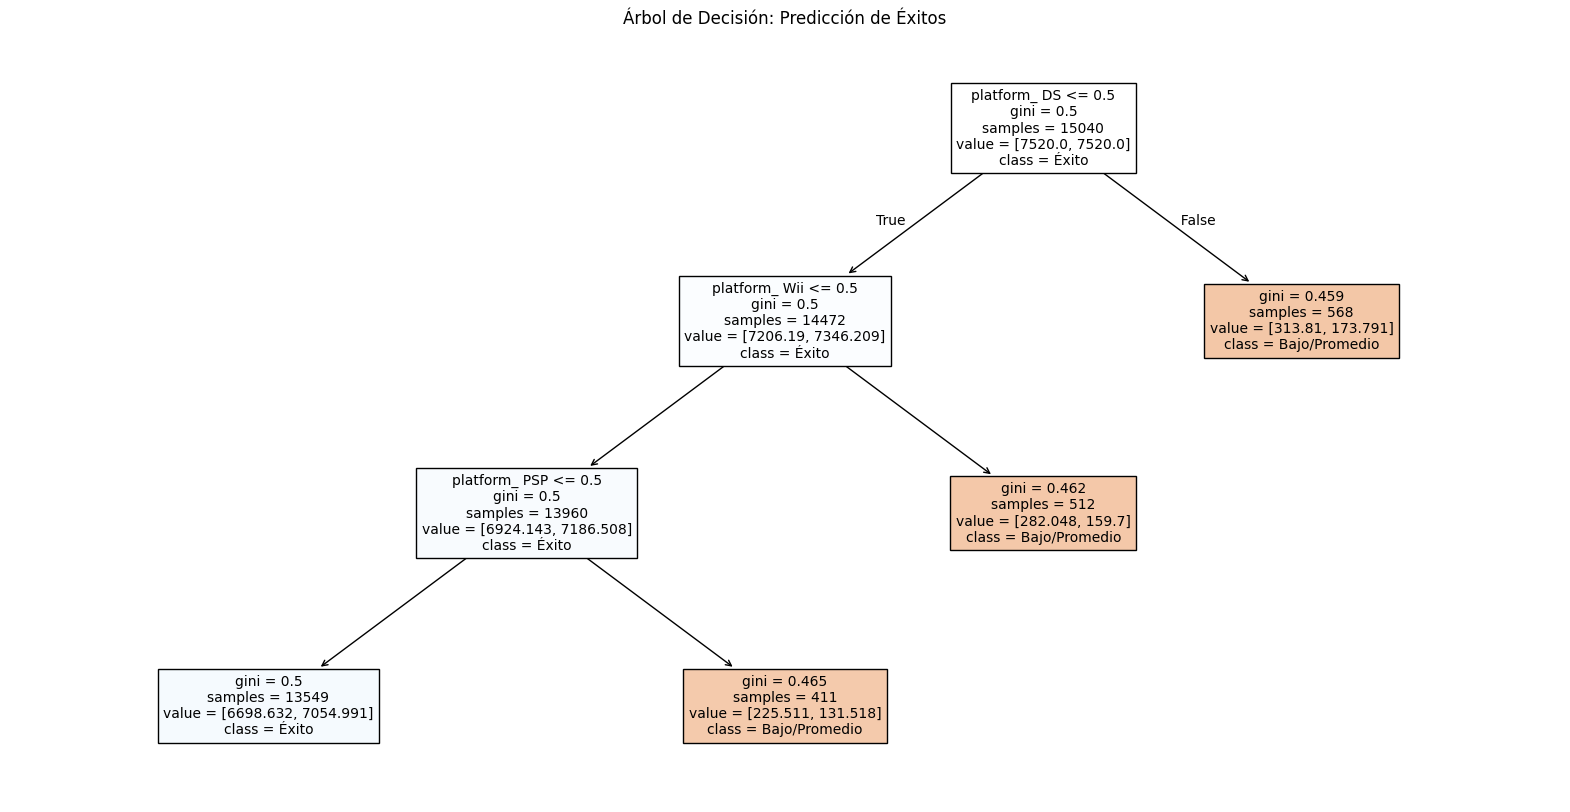

In [37]:
plt.figure(figsize=(20,10))
plot_tree(clf, filled=True, feature_names=list(X.columns),
class_names=['Bajo/Promedio', 'Éxito'], fontsize=10)
plt.title("Árbol de Decisión: Predicción de Éxitos")
plt.show()

# =====================================================
# F. PRUEBA CON NUEVOS DATOS (Predicción en Producción)
# =====================================================
# Función reutilizable para predecir NUEVOS juegos

In [59]:
def predecir_exito(platform, meta_score, modelo, columnas_plataformas):
  print(columnas_plataformas)
  """
  Predice si un juego es éxito.
  platform: 'PC', 'PS4', etc.
  meta_score: puntaje numérico (ej: 85)
  """
  nuevo_juego = pd.DataFrame({
    'platform': [platform],
    'meta_score': [meta_score]
  })
  X_nuevo = pd.get_dummies(nuevo_juego, drop_first=True)
  # Alinear columnas con el modelo entrenado
  for col in columnas_plataformas:
    if col not in X_nuevo.columns:
      X_nuevo[col] = 0
  X_nuevo = X_nuevo[columnas_plataformas]
  # Mismo orden
  prediccion = modelo.predict(X_nuevo)[0]
  probabilidad = modelo.predict_proba(X_nuevo)[0]
  resultado = " ÉXITO" if prediccion == 1 else " No éxito"
  print(f"Juego en {platform} con MetaScore {meta_score}: {resultado}")
  print(f"Probabilidad éxito: {probabilidad[1]:.1%}")
  return prediccion, probabilidad[1]

# Guardar columnas para reutilizar

In [60]:
columnas_plataformas = X.columns.tolist()

# EJEMPLOS DE PRUEBA

In [61]:
print("\n=== PRUEBAS CON JUEGOS NUEVOS ===")
predecir_exito('PC', 92, clf, columnas_plataformas)


=== PRUEBAS CON JUEGOS NUEVOS ===
['platform_ DS', 'platform_ Dreamcast', 'platform_ Game Boy Advance', 'platform_ GameCube', 'platform_ Nintendo 64', 'platform_ PC', 'platform_ PSP', 'platform_ PlayStation', 'platform_ PlayStation 2', 'platform_ PlayStation 3', 'platform_ PlayStation 4', 'platform_ PlayStation 5', 'platform_ PlayStation Vita', 'platform_ Stadia', 'platform_ Switch', 'platform_ Wii', 'platform_ Wii U', 'platform_ Xbox', 'platform_ Xbox 360', 'platform_ Xbox One', 'platform_ Xbox Series X']
Juego en PC con MetaScore 92:  ÉXITO
Probabilidad éxito: 51.3%


(np.int64(1), np.float64(0.5129551001622629))

In [56]:
predecir_exito('PS4', 80, clf, columnas_plataformas)

Juego en PS4 con MetaScore 80:  ÉXITO
Probabilidad éxito: 51.3%


(np.int64(1), np.float64(0.5129551001622629))

In [57]:
predecir_exito('Xbox', 60, clf, columnas_plataformas)

Juego en Xbox con MetaScore 60:  ÉXITO
Probabilidad éxito: 51.3%


(np.int64(1), np.float64(0.5129551001622629))

In [58]:
predecir_exito('Switch', 65, clf, columnas_plataformas)

Juego en Switch con MetaScore 65:  ÉXITO
Probabilidad éxito: 51.3%


(np.int64(1), np.float64(0.5129551001622629))